# 14 -- Version 1.0 Final Evaluation Review (READ-ONLY)

> **WATERMARK: FINAL-EVALUATION REVIEW NOTEBOOK -- NOT A DEVELOPMENT NOTEBOOK.**
> This notebook reviews the output of the single, sealed, already-completed
> Version 1.0 final evaluation (`evaluation/run_v1_final_evaluation.py`). It is
> the only place in this repository that ever displays real 2025 results.

Versions 0.2-0.12 are FROZEN, and the Version 1.0 final evaluation itself is
SEALED once it runs -- see CLAUDE.md "The one narrow exception: the sealed
Version 1.0 final evaluation" and `evaluation/run_v1_final_evaluation.py`'s
module docstring for the full policy.

## What this notebook is NOT

- It never downloads anything (no network access of any kind).
- It never fits, recalibrates, or retrains any model.
- It never scores any play, batter, or season -- it only reads
  `outputs/final_evaluation/v1/v1_final_report.json` and the public score
  table/leaderboards already written by a completed, sealed run.
- It never writes or modifies any file on disk.
- It is not a second evaluation entry point -- if you find yourself wanting
  to "just recompute one number here to check," that is a sign to go back to
  `evaluation/run_v1_final_evaluation.py`'s sealing rules, not to do it here.

## What this notebook DOES do before showing anything

Before displaying a single substantive result, it recomputes the report's
content hash and every frozen artifact's hash and compares them against the
sealed `seal.json` / `v1_final_report.json`'s own recorded manifest. If the
seal is missing, corrupted, or does not match, every results section below
prints a clear refusal instead of rendering -- see Section 1.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

sys.path.insert(0, str(Path("../evaluation").resolve()))

# Overridable via environment variable for offline structure/execution testing
# against a synthetic sealed fixture -- see tests/test_notebook_14_v1_review.py.
# Production default is the real, isolated Version 1.0 namespace.
ARTIFACTS_DIR = Path(
    __import__("os").environ.get(
        "CONTACT_LUCK_V1_ARTIFACTS_DIR", "../artifacts/final_evaluation/v1"
    )
)
OUTPUTS_DIR = Path(
    __import__("os").environ.get(
        "CONTACT_LUCK_V1_OUTPUTS_DIR", "../outputs/final_evaluation/v1"
    )
)
REPO_ROOT = Path(
    __import__("os").environ.get("CONTACT_LUCK_V1_REPO_ROOT", "..")
).resolve()

SEAL_PATH = ARTIFACTS_DIR / "seal.json"
REPORT_PATH = OUTPUTS_DIR / "v1_final_report.json"
PUBLIC_SCORE_PATH = OUTPUTS_DIR / "public_score_v1_final.json"
FAVORABLE_PATH = OUTPUTS_DIR / "favorable_leaderboard_v1_final.json"
UNFAVORABLE_PATH = OUTPUTS_DIR / "unfavorable_leaderboard_v1_final.json"

print(f"Reading seal from:   {SEAL_PATH}")
print(f"Reading report from: {REPORT_PATH}")


Reading seal from:   ../artifacts/final_evaluation/v1/seal.json
Reading report from: ../outputs/final_evaluation/v1/v1_final_report.json


## 1. Seal verification -- MUST pass before anything substantive is shown

Recomputes `report_content_hash` (the exact same SHA-256-of-canonical-JSON
scheme `evaluation.run_v1_final_evaluation.hash_report` uses) and every
frozen artifact's SHA-256 (the same scheme
`evaluation.v1_final_evaluation_manifest.compute_file_sha256` uses), and
compares both against the sealed values. `SEAL_OK` gates every later
section -- if it is `False`, every remaining section refuses to render.


In [2]:
from run_v1_final_evaluation import hash_report
from v1_final_evaluation_manifest import compute_file_sha256

SEAL_OK = False
SEAL_FAILURE_REASONS = []

seal = json.loads(SEAL_PATH.read_text()) if SEAL_PATH.exists() else None
report = json.loads(REPORT_PATH.read_text()) if REPORT_PATH.exists() else None

if seal is None:
    SEAL_FAILURE_REASONS.append(f"No seal file found at {SEAL_PATH}.")
if report is None:
    SEAL_FAILURE_REASONS.append(f"No final report found at {REPORT_PATH}.")

if seal is not None and report is not None:
    recomputed_report_hash = hash_report(report)
    if recomputed_report_hash != seal.get("report_content_hash"):
        SEAL_FAILURE_REASONS.append(
            "Report content hash does not match the sealed hash -- the report file has "
            "changed since it was sealed, or the seal belongs to a different report."
        )

    stored_artifact_hashes = report.get("manifest", {}).get("artifact_hashes", {})
    if not stored_artifact_hashes:
        SEAL_FAILURE_REASONS.append("Report's manifest has no artifact_hashes to verify.")
    else:
        mismatched = []
        for rel_path, expected_hash in stored_artifact_hashes.items():
            full_path = REPO_ROOT / rel_path
            if not full_path.is_file():
                mismatched.append((rel_path, "missing"))
                continue
            current_hash = compute_file_sha256(full_path)
            if current_hash != expected_hash:
                mismatched.append((rel_path, "changed"))
        if mismatched:
            SEAL_FAILURE_REASONS.append(
                f"{len(mismatched)} frozen artifact(s) no longer match the sealed hashes: "
                f"{mismatched}"
            )

    if not SEAL_FAILURE_REASONS:
        SEAL_OK = True

if SEAL_OK:
    print("SEAL VERIFIED -- report content hash and every frozen artifact hash match.")
    print(f"Sealed at: {seal['sealed_at']}  |  commit: {seal['repository_commit']}")
    if seal.get("defect_fix_of"):
        print(f"This is a defect-fix rerun of a prior seal from: {seal['defect_fix_of']}")
else:
    print("SEAL INVALID OR ABSENT -- refusing to render substantive results below.")
    for reason in SEAL_FAILURE_REASONS:
        print(f"  - {reason}")


SEAL VERIFIED -- report content hash and every frozen artifact hash match.
Sealed at: 2026-08-06T02:57:07.121140+00:00  |  commit: 53a4ca7d9f68138b68d46e48169ad7dbaa8ef059


## 2. Outcome classification

The predeclared outcome (`validated_as_frozen`, `validated_with_documented_
limitations`, or `final_evaluation_failed`) and the exact reasons the
classification rule (fixed BEFORE this evaluation ever ran -- see
`evaluation.v1_final_report.classify_final_evaluation_outcome`) produced.


In [3]:
if SEAL_OK:
    outcome_block = report["outcome_classification"]
    banner = {
        "validated_as_frozen": "\N{WHITE HEAVY CHECK MARK} VALIDATED AS FROZEN",
        "validated_with_documented_limitations": (
            "\N{WARNING SIGN} VALIDATED WITH DOCUMENTED LIMITATIONS"
        ),
        "final_evaluation_failed": "\N{CROSS MARK} FINAL EVALUATION FAILED",
    }.get(outcome_block["outcome"], outcome_block["outcome"])
    print(banner)
    print()
    for reason in outcome_block["reasons"]:
        print(f"  - {reason}")
else:
    print("Skipped -- no valid seal.")


⚠ VALIDATED WITH DOCUMENTED LIMITATIONS

  - one or more provisional components, subgroup limitations, or meaningful distribution shifts remain, with no critical pipeline or validity failure


## 3. Frozen score definition and retrospective limitation

The exact, centralized public language (`mlb_luck_score.scoring.
public_labels`) -- never paraphrased here.


In [4]:
if SEAL_OK:
    from mlb_luck_score.scoring.public_labels import (
        CONTACT_LUCK_RUNS_DEFINITION,
        CONTACT_LUCK_RUNS_LABEL,
        CONTACT_LUCK_RUNS_PER_100_DEFINITION,
        CONTACT_LUCK_RUNS_PER_100_LABEL,
        RETROSPECTIVE_LIMITATION,
    )

    print(f"{CONTACT_LUCK_RUNS_LABEL}: {CONTACT_LUCK_RUNS_DEFINITION}")
    print(f"{CONTACT_LUCK_RUNS_PER_100_LABEL}: {CONTACT_LUCK_RUNS_PER_100_DEFINITION}")
    print()
    print(RETROSPECTIVE_LIMITATION)
else:
    print("Skipped -- no valid seal.")


Contact Luck Runs: The number of runs by which a batter's observed eligible batted-ball outcomes were more or less favorable than the model expected.
Contact Luck Runs per 100: Contact Luck Runs normalized to 100 eligible batted balls.

Contact Luck is a retrospective description of realized outcomes, not a measure of stable batting talent and not a projection of future performance.


## 4. System-level checks (accounting, routing, reproducibility, contract)

Every required structural check from `evaluation.v1_system_evaluation`,
re-run on 2025 and recorded in the sealed report -- never recomputed here.


In [5]:
if SEAL_OK:
    for name, result in report["system_checks"].items():
        print(f"--- {name} ---")
        print(json.dumps(result, indent=2, default=str))
        print()
else:
    print("Skipped -- no valid seal.")


--- play_level_accounting ---
{
  "identity_holds_for_every_resolved_row": true,
  "resolved_row_count": 128467,
  "abs_reconciliation_error": {
    "max": 2.220446049250313e-16,
    "median": 0.0,
    "p95": 0.0,
    "p99": 2.7755575615628914e-17
  }
}

--- season_level_accounting ---
{
  "identity_holds_for_every_row": true,
  "row_count": 1156,
  "abs_reconciliation_error": {
    "max": 5.329070518200751e-15,
    "median": 0.0,
    "p95": 1.7763568394002505e-15,
    "p99": 2.4202861936828615e-15
  }
}

--- routing_exclusivity ---
{
  "mutually_exclusive": true,
  "outfield_eligible_rows": 59992,
  "infield_eligible_rows": 36533,
  "neither_domain_rows": 33404
}

--- advancement_eligibility_subset ---
{
  "advancement_eligible_rows": 22417,
  "subset_of_outfield_air_balls": true
}

--- event_ids ---
{
  "unique_non_null_event_ids": true,
  "row_count": 129929
}

--- no_experimental_components ---
{
  "no_weather_or_alignment_columns_in_official_ledger": true
}

--- bootstrap_reproduc

## 5. Component metrics and calibration statuses

Contact, open-field outfield, infield, and advancement components, plus the
near-wall specialist -- **labeled explicitly** as provisional/frozen
regardless of how it performed on 2025 (Version 0.7 stays frozen; see
CLAUDE.md).


In [6]:
if SEAL_OK:
    component_metrics = report["component_metrics"]
    near_wall = component_metrics.get("near_wall_specialist", {})
    print(
        f"near_wall_specialist status: {near_wall.get('status')!r} -- "
        f"{near_wall.get('status_reason')}"
    )
    print()
    for name in ("contact_model", "open_field_outfield_model", "infield_model", "advancement_model"):
        if name in component_metrics:
            print(f"--- {name} ---")
            print(json.dumps(component_metrics[name], indent=2, default=str)[:2000])
            print()
else:
    print("Skipped -- no valid seal.")


near_wall_specialist status: 'provisional' -- Version 0.7 is frozen; the near-wall specialist is never adopted from a single final-evaluation run regardless of 2025 performance

--- contact_model ---
{
  "variant": "unweighted_probability_baseline",
  "class_weight": null,
  "sample_count": 126386,
  "multiclass_log_loss": 0.6715066318699864,
  "brier_score_by_class": {
    "out": 0.16648957534638983,
    "single": 0.13730183668600512,
    "double": 0.052555208118941564,
    "triple": 0.005078429709729302,
    "home_run": 0.01804657637868969
  },
  "confusion_matrix": [
    [
      77827,
      4405,
      1920,
      2,
      1063
    ],
    [
      14987,
      11411,
      350,
      0,
      12
    ],
    [
      3569,
      2418,
      1468,
      2,
      506
    ],
    [
      337,
      128,
      72,
      0,
      111
    ],
    [
      1467,
      1,
      202,
      0,
      4128
    ]
  ],
  "confusion_matrix_labels": [
    "out",
    "single",
    "double",
    "triple",


## 6. Distribution shift: 2025 vs. 2021-2024 development reference

Descriptive only (SMD/PSI) -- flags a shift, never corrects one, and never
feeds back into any frozen model or threshold.


In [7]:
if SEAL_OK:
    shift = report["distribution_shift"]
    print(f"{len(shift['flags'])} flagged shift(s):")
    for flag in shift["flags"]:
        print(f"  - {flag}")
else:
    print("Skipped -- no valid seal.")


2 flagged shift(s):
  - categorical_features.venue_mix: PSI major_shift (0.7860024587270066)
  - categorical_features.infield_alignment_labels: PSI major_shift (1.2218693114561219)


## 7. Qualification summary and interval-width distribution

Qualification counts, share qualified, and the distribution of 95%
game_pk-clustered bootstrap interval widths among qualified rows.


In [8]:
if SEAL_OK:
    pub_summary = report["public_score_evaluation"]
    print(f"n_batter_seasons: {pub_summary['n_batter_seasons']}")
    print(f"n_qualified: {pub_summary['n_qualified']}")
    print(f"share_qualified: {pub_summary['share_qualified']}")
    print()
    print("Interval width distribution (qualified rows):")
    print(json.dumps(pub_summary["interval_width_distribution"], indent=2))
    print()
    print("Qualified interval interpretation shares:")
    print(json.dumps(pub_summary["qualified_interval_interpretation_shares"], indent=2))
else:
    print("Skipped -- no valid seal.")


n_batter_seasons: 1156
n_qualified: 231
share_qualified: 0.19982698961937717

Interval width distribution (qualified rows):
{
  "mean": 7.597930319013868,
  "median": 7.429993278105707,
  "min": 5.419638248782712,
  "max": 10.930368634881617
}

Qualified interval interpretation shares:
{
  "entirely_above_zero": 10,
  "overlaps_zero": 205,
  "entirely_below_zero": 16
}


## 8. Point estimates with intervals -- visible zero reference

Every displayed point estimate is shown WITH its interval, and a vertical
line at zero makes "interval crosses zero" immediately visible (never a
significance claim -- see `RETROSPECTIVE_LIMITATION` above).


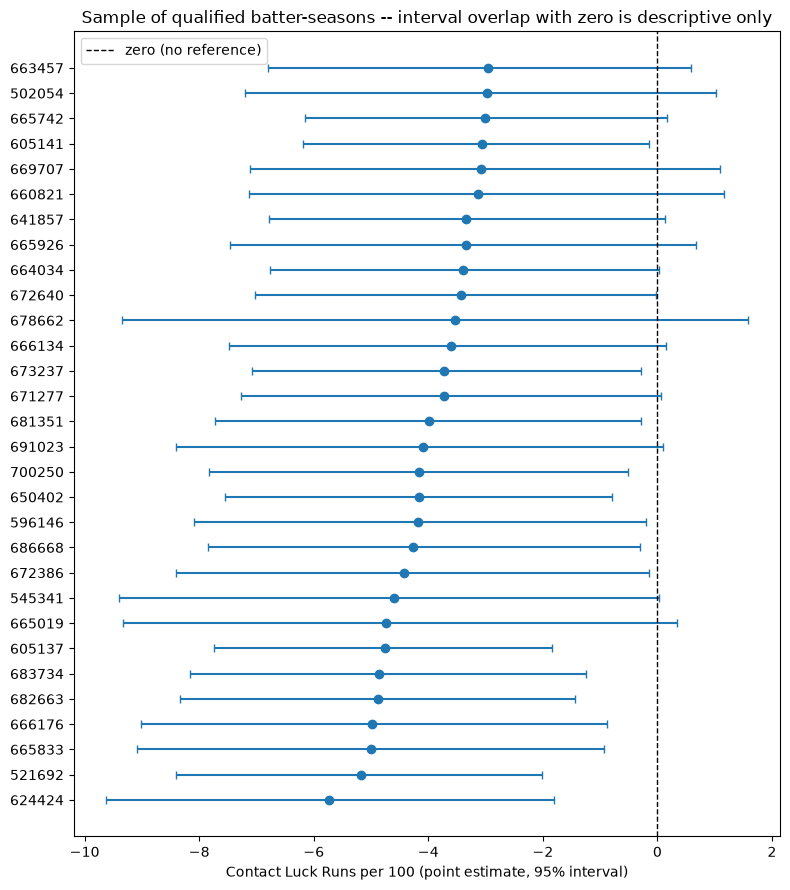

In [9]:
if SEAL_OK and PUBLIC_SCORE_PATH.exists():
    public_score_table = pd.read_json(PUBLIC_SCORE_PATH)
    qualified = public_score_table[public_score_table["qualification_status"] == "qualified"]
    sample = qualified.sort_values("contact_luck_runs_per_100").head(30)

    fig, ax = plt.subplots(figsize=(8, max(4, len(sample) * 0.3)))
    y = range(len(sample))
    ax.errorbar(
        sample["contact_luck_runs_per_100"],
        y,
        xerr=[
            sample["contact_luck_runs_per_100"] - sample["lower_95_interval"],
            sample["upper_95_interval"] - sample["contact_luck_runs_per_100"],
        ],
        fmt="o",
        capsize=3,
    )
    ax.axvline(0, color="black", linewidth=1, linestyle="--", label="zero (no reference)")
    ax.set_yticks(list(y))
    ax.set_yticklabels(sample["batter_id"].astype(str).tolist())
    ax.set_xlabel("Contact Luck Runs per 100 (point estimate, 95% interval)")
    ax.set_title("Sample of qualified batter-seasons -- interval overlap with zero is descriptive only")
    ax.legend()
    plt.tight_layout()
    plt.show()
elif SEAL_OK:
    print(f"No public score table found at {PUBLIC_SCORE_PATH}.")
else:
    print("Skipped -- no valid seal.")


## 9. Stability analyses

Split-half/odd-even reliability within 2025, interval width by sample size,
and (if a 2024 comparison table was supplied to the sealed run) the
2024-vs-2025 cross-season correlation among dual-qualified players. Low
correlation here is CONSISTENT with Contact Luck's retrospective purpose --
never a predictive-validity failure (see Section 3's limitation language).


In [10]:
if SEAL_OK:
    stability = report["stability"]
    print(json.dumps(stability, indent=2, default=str)[:4000])
else:
    print("Skipped -- no valid seal.")


{
  "split_half_2025": {
    "calendar": {
      "split": "calendar",
      "metric": "observed_minus_expected_per_100",
      "min_eligible_each_half": 20,
      "n_players_compared": 403,
      "pearson_r": 0.03801865179444384,
      "spearman_r": 0.055469892754247095
    },
    "odd_even_game_pk": {
      "split": "odd_even",
      "metric": "observed_minus_expected_per_100",
      "min_eligible_each_half": 20,
      "n_players_compared": 502,
      "pearson_r": 0.10071796922015187,
      "spearman_r": 0.14002010315661675
    }
  },
  "interval_width_by_sample_size_2025": [
    {
      "n_games_bin": "(0.999, 3.0]",
      "n_players": 479,
      "median_n_games": 1.0,
      "median_interval_width": 0.0
    },
    {
      "n_games_bin": "(3.0, 31.0]",
      "n_players": 213,
      "median_n_games": 13.0,
      "median_interval_width": 23.854846994200038
    },
    {
      "n_games_bin": "(31.0, 102.0]",
      "n_players": 227,
      "median_n_games": 60.0,
      "median_interval_widt

## 10. Leaderboards

"Most favorable realized luck" and "least favorable outcomes relative to
expectation" -- qualified rows only, competition ranking.


In [11]:
if SEAL_OK and FAVORABLE_PATH.exists() and UNFAVORABLE_PATH.exists():
    favorable_leaderboard = pd.read_json(FAVORABLE_PATH)
    unfavorable_leaderboard = pd.read_json(UNFAVORABLE_PATH)
    print("Most favorable realized luck:")
    display(favorable_leaderboard.head(25))
    print("Least favorable outcomes relative to expectation:")
    display(unfavorable_leaderboard.head(25))
elif SEAL_OK:
    print("Leaderboard file(s) not found.")
else:
    print("Skipped -- no valid seal.")


Most favorable realized luck:


,official_rank_favorable,batter_id,batter_name,season,contact_luck_runs_per_100,lower_95_interval,upper_95_interval,interval_interpretation,eligible_batted_balls,games,total_contact_luck_runs
0,1,664056,NaN,2025,5.804491,1.679665,9.802481,entirely_above_zero,322,133,18.690462
1,2,665862,NaN,2025,5.002553,-0.203940,10.404966,overlaps_zero,323,128,16.158246
2,3,656716,NaN,2025,4.789390,0.654985,9.078691,entirely_above_zero,357,143,17.098122
3,4,686217,NaN,2025,4.741402,1.711085,7.924930,entirely_above_zero,456,141,21.620793
4,5,656811,NaN,2025,4.496859,0.051669,9.135103,entirely_above_zero,373,139,16.773285
5,6,607208,NaN,2025,4.231832,0.661393,7.701006,entirely_above_zero,482,145,20.397429
6,7,666158,NaN,2025,4.155935,0.172238,8.085567,entirely_above_zero,338,133,14.047060
7,8,686555,NaN,2025,4.053775,-0.439854,8.967439,overlaps_zero,290,119,11.755947
8,9,669065,NaN,2025,3.997009,-0.707938,8.791898,overlaps_zero,287,112,11.471415
9,10,682829,NaN,2025,3.677474,0.192754,6.975802,entirely_above_zero,454,165,16.695734


Least favorable outcomes relative to expectation:


,official_rank_unfavorable,batter_id,batter_name,season,contact_luck_runs_per_100,lower_95_interval,upper_95_interval,interval_interpretation,eligible_batted_balls,games,total_contact_luck_runs
0,1,624424,NaN,2025,-5.725040,-9.629304,-1.797605,entirely_below_zero,305,130,-17.461371
1,2,521692,NaN,2025,-5.166547,-8.412217,-2.019797,entirely_below_zero,485,159,-25.057752
2,3,665833,NaN,2025,-5.000730,-9.077030,-0.934061,entirely_below_zero,300,127,-15.002190
3,4,666176,NaN,2025,-4.980278,-9.008991,-0.885777,entirely_below_zero,385,149,-19.174070
4,5,682663,NaN,2025,-4.877503,-8.336103,-1.440336,entirely_below_zero,422,136,-20.583065
5,6,683734,NaN,2025,-4.865222,-8.164335,-1.245413,entirely_below_zero,341,115,-16.590408
6,7,605137,NaN,2025,-4.747010,-7.734580,-1.840442,entirely_below_zero,389,136,-18.465869
7,8,665019,NaN,2025,-4.736649,-9.330098,0.346732,overlaps_zero,272,111,-12.883685
8,9,545341,NaN,2025,-4.593897,-9.407436,0.031738,overlaps_zero,218,105,-10.014696
9,10,672386,NaN,2025,-4.424551,-8.412862,-0.143491,entirely_below_zero,404,129,-17.875185


## 11. Limitations

Every documented limitation carried into `validated_with_documented_
limitations` (if that was the outcome) -- distribution-shift flags and/or
provisional-component status, never silently dropped.


In [12]:
if SEAL_OK:
    limitations = report.get("limitations", [])
    if limitations:
        for item in limitations:
            print(f"  - {item}")
    else:
        print("No limitations recorded.")
else:
    print("Skipped -- no valid seal.")


  - categorical_features.venue_mix: PSI major_shift (0.7860024587270066)
  - categorical_features.infield_alignment_labels: PSI major_shift (1.2218693114561219)


## 12. Ingestion provenance

Exact 2025 date range requested, source, retrieval timestamp, raw file
hashes, row/game counts, and join coverage -- recorded once, at ingestion
time, by the sealed run itself (never recomputed here).


In [13]:
if SEAL_OK:
    print(json.dumps(report.get("ingestion_provenance", {}), indent=2, default=str)[:4000])
else:
    print("Skipped -- no valid seal.")


{
  "raw_statcast": {
    "source": "pybaseball.statcast (Baseball Savant)",
    "requested_date_range": [
      "2025-03-18",
      "2025-09-28"
    ],
    "retrieved_at": "2026-08-06T02:51:55.327628+00:00",
    "raw_file_path": "/Users/arihantaneja/Downloads/TrueLuckMLBStat/data/final_evaluation/2025/statcast_2025_regular_season.parquet",
    "raw_file_sha256": "95bd8ef22cf6615fbf36bab95ef61328ba8fc70a1ad2b07cd35a3a63b51a71a0",
    "row_count": 742080,
    "observed_date_coverage": [
      "2025-03-18",
      "2025-09-28"
    ],
    "missing_dates_within_range": [
      "2025-03-26",
      "2025-07-14",
      "2025-07-15",
      "2025-07-16",
      "2025-07-17"
    ],
    "schema_check": {
      "missing_required_columns": [],
      "incompatible_numeric_columns": [],
      "extra_columns_present": [
        "age_bat",
        "age_bat_legacy",
        "age_pit",
        "age_pit_legacy",
        "api_break_x_arm",
        "api_break_x_batter_in",
        "api_break_z_with_gravity",


---

**End of Version 1.0 final-evaluation review.** This notebook rendered
results ONLY because the seal verification in Section 1 passed. Re-running
this notebook after the underlying report/artifacts change (a new commit, an
edited frozen file, a defect-fix reseal) will correctly show a refusal until
Section 1 is satisfied again.
